# 06. 階層ベイズ — グループ同士が情報を貸し借りする

## この章で分かること

- 3 つの推定戦略: **非プーリング・完全プーリング・部分プーリング(階層ベイズ)**
- **shrinkage(縮小)**: 観測の少ないグループほど全体平均に引き寄せられる
- なぜそれが「正しい」のか — 小標本の極端な値はほぼノイズだから
- 店舗別 CVR・選手別打率での実演

03 章と並ぶ本書のコアです。階層ベイズは「ベイズで一番気持ちいい瞬間」がある章です。

## 1. Problem — 12 店舗の CVR、どう推定する?

店舗別のコンバージョンデータがあります。訪問数は店舗によって 20 〜 3,000 と桁違い。

**訪問 20 件で CV 3 件の店(CVR 15%!)を、本当に 15% と信じてよいか?**

3 つの戦略が考えられます:

| 戦略 | やり方 | 問題点 |
|---|---|---|
| **非プーリング** | 店舗ごとに別々に $s_i/n_i$ | 小標本の店が極端な値になる |
| **完全プーリング** | 全店まとめて 1 つの率 | 店舗差を無視してしまう |
| **部分プーリング** | 店舗差を認めつつ、共通の事前分布で繋ぐ | — これが階層ベイズ |

```{admonition} 核心 — ひとことで
:class: tip
**階層ベイズは「グループ差を認めつつ、共通の事前分布で情報を貸し借りする」＝部分プーリング。**
各グループの事後平均は加重平均で、観測の少ないグループほど全体平均へ強く縮む（shrinkage）。
縮小の強さはデータ量で自動調整され、非プーリングと完全プーリングの間を滑らかに動く（RMSE で両者に勝つ＝Stein 現象）。
```

In [1]:
# Shared setup + the store data (same generator as data/store_conversions.csv).
import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio

from bayes_textbook import visualization as viz
from bayes_textbook.models import fit_partial_pooling_beta, fit_partial_pooling_normal
from bayes_textbook.simulation import make_store_conversions, make_batting_data

pio.renderers.default = "plotly_mimetype+notebook_connected"
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

stores = make_store_conversions(n_stores=12, seed=42)
stores["raw_rate"] = stores["conversions"] / stores["visits"]
print(stores[["store", "visits", "conversions", "raw_rate"]].to_string(index=False))

store  visits  conversions  raw_rate
  S00     503           19  0.037773
  S01    1234           41  0.033225
  S02     184           10  0.054348
  S03      62            6  0.096774
  S04     322           12  0.037267
  S05      27            3  0.111111
  S06    1264           83  0.065665
  S07     473           25  0.052854
  S08     892           56  0.062780
  S09     118            5  0.042373
  S10    2590          199  0.076834
  S11    1756          133  0.075740


生の率(非プーリング)を見ると、訪問数の少ない店ほど極端な値が出がちです。
これは店の実力ではなく **標本サイズの小ささが作るノイズ** です。

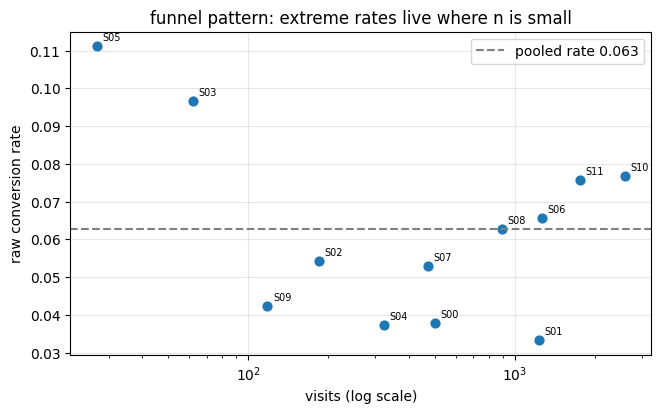

In [2]:
# Raw rates vs sample size: small samples produce extreme rates.
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(stores["visits"], stores["raw_rate"], s=40)
pooled = stores["conversions"].sum() / stores["visits"].sum()
ax.axhline(pooled, color="gray", ls="--", label=f"pooled rate {pooled:.3f}")
for _, row in stores.iterrows():
    ax.annotate(row["store"], (row["visits"], row["raw_rate"]),
                textcoords="offset points", xytext=(4, 4), fontsize=7)
ax.set_xscale("log")
ax.set_xlabel("visits (log scale)")
ax.set_ylabel("raw conversion rate")
ax.set_title("funnel pattern: extreme rates live where n is small")
ax.grid(alpha=0.3); ax.legend()
plt.show()

## 2. 階層モデル — 仮説と事前分布

**仮説**: 各店舗の真の CVR $\theta_i$ は店ごとに違うが、**同じ母集団から来ている**。

$$
\theta_i \sim \mathrm{Beta}(\alpha_0, \beta_0)
$$

$$
x_i \sim \mathrm{Binomial}(n_i, \theta_i)
$$

ポイントは、各店の事前分布 $\mathrm{Beta}(\alpha_0, \beta_0)$ を
**「他の店たちのデータ」から決める** こと(ここでは経験ベイズ: 全店の率のばらつきから
モーメント法で推定)。すると各店の事後平均は:

$$
\mathbb{E}[\theta_i \mid x_i] = w_i \cdot \frac{x_i}{n_i} + (1 - w_i) \cdot \frac{\alpha_0}{\alpha_0 + \beta_0},
\qquad w_i = \frac{n_i}{\alpha_0 + \beta_0 + n_i}
$$

03 章と同じ加重平均ですが、今度は **重み $w_i$ が店ごとに違う**:

- 大型店($n_i$ 大)→ $w_i \approx 1$ → 自分のデータを信じる
- 小型店($n_i$ 小)→ $w_i \approx 0$ → 仲間の平均を借りる

これが **shrinkage** です。

estimated shared prior: Beta(6.1, 91.0)  (pseudo-data strength = 97 visits)


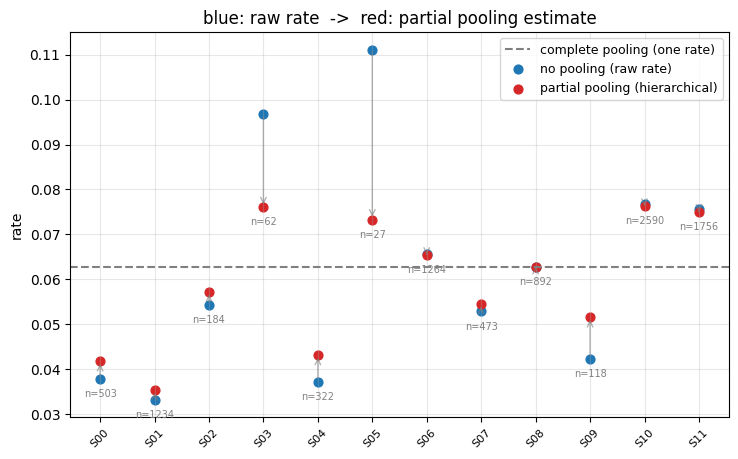

In [3]:
# Partial pooling: small stores shrink toward the pool, big stores barely move.
res = fit_partial_pooling_beta(stores["conversions"], stores["visits"])
print(f"estimated shared prior: Beta({res.prior.alpha:.1f}, {res.prior.beta:.1f})  "
      f"(pseudo-data strength = {res.prior.alpha + res.prior.beta:.0f} visits)")

viz.plot_shrinkage(res, group_labels=stores["store"], sizes=stores["visits"])
plt.title("blue: raw rate  ->  red: partial pooling estimate")
plt.show()

矢印の長さ = 縮小量。**訪問数の少ない店ほど長い矢印で全体平均へ引かれ、
大型店はほぼ動かない**。これこそ階層ベイズの動作そのものです。

## 3. どちらが当たるのか — 真の率との答え合わせ

このデータは合成なので、真の CVR を知っています。
3 つの戦略の推定誤差(RMSE)を比べると、部分プーリングの価値が数字で出ます。

In [4]:
# Ground-truth scoring: partial pooling wins on RMSE.
true_rates = stores["true_rate"].to_numpy()


def rmse(est):
    return float(np.sqrt(np.mean((est - true_rates) ** 2)))


print(f"no pooling (raw)   : RMSE = {rmse(res.unpooled):.4f}")
print(f"complete pooling   : RMSE = {rmse(np.full(len(stores), res.pooled)):.4f}")
print(f"partial pooling    : RMSE = {rmse(res.partial):.4f}")

no pooling (raw)   : RMSE = 0.0240
complete pooling   : RMSE = 0.0169
partial pooling    : RMSE = 0.0143


非プーリングは小型店のノイズをそのまま食らい、完全プーリングは店舗差を捨てて外す。
部分プーリングは **両者のいいとこ取り** で、たいてい両方に勝ちます
(これは偶然ではなく、Stein のパラドックスとして知られる一般現象 — §7)。

## 4. 観測数を動かして shrinkage を体感する

全店舗の訪問数を一斉にスケールしたとき、縮小がどう変わるかを見ます。

- データが乏しい(×0.1)→ 全店が共通平均へ強く縮む(ほぼ完全プーリング)
- データが豊富(×10)→ ほぼ縮まない(ほぼ非プーリング)

**階層ベイズはデータ量に応じて 2 つの極端の間を自動で動く** のです。

In [5]:
# Plotly slider: scale all sample sizes, watch shrinkage strengthen / relax.
base = make_store_conversions(n_stores=10, seed=42)
order = np.argsort(base["visits"].to_numpy())
frames = []
x_idx = np.arange(len(base))
for factor in [0.1, 0.3, 1.0, 3.0, 10.0]:
    visits = np.maximum(1, (base["visits"].to_numpy() * factor).astype(int))
    conv = np.random.default_rng(0).binomial(visits, base["true_rate"].to_numpy())
    r = fit_partial_pooling_beta(conv, visits)
    frames.append((f"x{factor:g}",
                   [("raw rate", r.unpooled[order], "dot"),
                    ("partial pooling", r.partial[order], None),
                    ("pooled", np.full(len(base), r.pooled), "dash")]))
fig = viz.plotly_curve_slider(x_idx, frames, slider_name="sample size scale",
                              title="shrinkage adapts to data volume (stores sorted by visits)")
fig.update_xaxes(title="store (small n -> large n)")
fig.update_yaxes(title="rate")
fig.show()

### インタラクティブ(JupyterLab のみ)

In [6]:
# Interactive (JupyterLab only): same idea with a live slider.
from bayes_textbook.widgets import interactive_hierarchical_shrinkage

interactive_hierarchical_shrinkage()

interactive(children=(FloatLogSlider(value=1.0, description='size_factor', max=1.0, min=-1.5, step=0.25), Outp…

<function bayes_textbook.widgets.interactive_hierarchical_shrinkage.<locals>.draw(size_factor)>

## 5. 打率の例 — 開幕 10 打席の 4 割打者

開幕直後の「打率 .400 の選手」を、シーズン .400 と予測する人はいません。
誰もが「そのうち .280 くらいに落ち着く」と直感します —
**人間は自然に shrinkage をやっている** のです。階層ベイズはそれを定量化します。

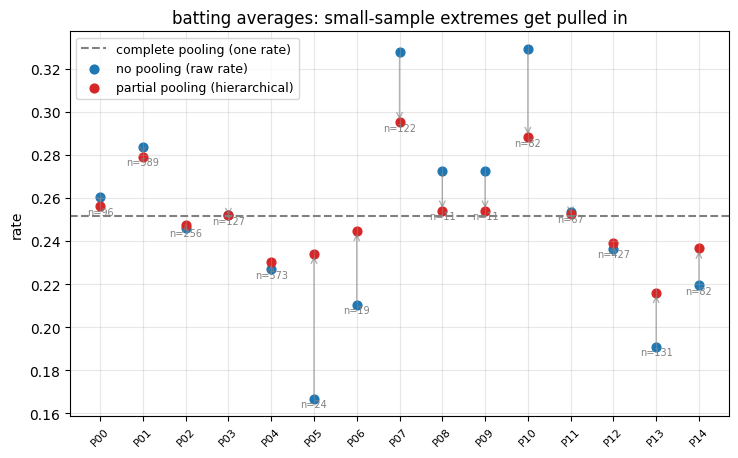

players with <50 at-bats: raw RMSE 0.0499  -> partial 0.0121


In [7]:
# Batting averages: the .400 hitter with 10 at-bats gets shrunk hard.
bat = make_batting_data(n_players=15, seed=7)
bat["raw_avg"] = bat["hits"] / bat["at_bats"]
res_bat = fit_partial_pooling_beta(bat["hits"], bat["at_bats"])

viz.plot_shrinkage(res_bat, group_labels=bat["player"], sizes=bat["at_bats"])
plt.title("batting averages: small-sample extremes get pulled in")
plt.show()

few = bat["at_bats"] < 50
print(f"players with <50 at-bats: raw RMSE {np.sqrt(np.mean((res_bat.unpooled[few] - bat['true_avg'][few])**2)):.4f}  "
      f"-> partial {np.sqrt(np.mean((res_bat.partial[few] - bat['true_avg'][few])**2)):.4f}")

## 6. 正規版 — 8 schools 型の階層モデル

率ではなく **効果量(平均値)** の階層化もまったく同じ構図です。
グループ $i$ の観測平均 $y_i$(標準誤差 $se_i$)に対し:

$$
\theta_i \sim \mathcal{N}(\mu, \tau^2), \qquad y_i \sim \mathcal{N}(\theta_i, se_i^2)
$$

$\tau$(グループ間のばらつき)が小さければ強くプーリング、大きければ個別推定に近づく。
`fit_partial_pooling_normal` は $\tau$ を周辺尤度最大化で推定します。
題材は統計学で最も有名な階層データ **8 schools** — そして結果には有名な「落とし穴」が待っています。

estimated mu = 7.69, tau = 0.00


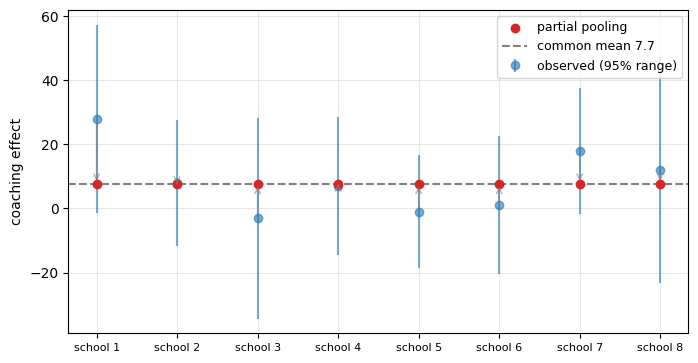

In [8]:
# The classic 8-schools data: coaching effects with big standard errors.
y = np.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0])
se = np.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0])
shrunk, mu_hat, tau_hat = fit_partial_pooling_normal(y, se)
print(f"estimated mu = {mu_hat:.2f}, tau = {tau_hat:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
xs = np.arange(8)
ax.errorbar(xs, y, yerr=1.96 * se, fmt="o", color="#1f77b4", alpha=0.6, label="observed (95% range)")
ax.scatter(xs, shrunk, color="#d62728", zorder=3, label="partial pooling")
ax.axhline(mu_hat, color="gray", ls="--", label=f"common mean {mu_hat:.1f}")
for i in range(8):
    ax.annotate("", xy=(xs[i], shrunk[i]), xytext=(xs[i], y[i]),
                arrowprops={"arrowstyle": "->", "color": "gray", "alpha": 0.6})
ax.set_xticks(xs, [f"school {i+1}" for i in xs], fontsize=8)
ax.set_ylabel("coaching effect")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.show()

出力に注目してください: **$\hat\tau = 0.00$**。これは実装のバグではなく、
8 schools の周辺尤度は $\tau = 0$ で最大になるという **有名な結果** です
(各校の標準誤差が大きすぎて、学校間の真の差をデータが支持できない)。

$\tau = 0$ ということは、この経験ベイズ推定は **完全プーリングまで縮めてしまった**
ということです(図の赤点はすべて共通平均 7.69 に乗っています)。
school 1 の「効果 28」は標準誤差 15 の上のノイズとして全額引き戻されました。

これは経験ベイズの限界を示す教科書的な瞬間でもあります:
$\tau$ を **点推定** すると、$\tau > 0$ の可能性(学校差が本当はあるかもしれない)が
事後から消えてしまう。$\tau$ にも事前分布を置く **フルベイズ**(08 章)なら
$\tau$ の事後に正の質量が残り、各校の推定は完全プーリングと個別推定の **中間** に落ち着きます。
店舗 CVR(グループ数 12・大標本店あり)で経験ベイズが上手くいったのとは対照的に、
**全グループが小標本のとき、経験ベイズとフルベイズの差は本物** になります。

## 7. Failure Mode と理論メモ

- **グループが異質すぎる場合**: 「同じ母集団から来ている」仮説が壊れていると、
  縮小は害になる(例: 業態の違う店舗を混ぜる)。階層の切り方はドメイン知識の仕事。
- **グループ数が少なすぎる**(2〜3 個): $\tau$ や事前の推定が不安定。
  完全ベイズ($\tau$ にも事前を置く、08 章)が頑健。
- **経験ベイズの過信**: 本章は事前をデータから点推定した(経験ベイズ)。
  事前のパラメータ自体の不確実性は無視しており、8 schools のように $\hat\tau = 0$ へ
  潰れることもある(§6)。また、観測率の分散には二項ノイズも乗るため、
  §2 の素朴なモーメント法は $\kappa$ を小さめに見積もる(= 縮小が弱めになる)傾向がある
  — 実際 08 章のフルベイズでは $\kappa$ の事後平均が本章の点推定の約 2 倍に出る。
  フルベイズとの比較は 08 章で。
- **Stein のパラドックス**: 3 グループ以上の平均の同時推定では、縮小推定が
  各グループ独立の推定を **常に**(全体の二乗誤差で)上回り得る。
  「borrowing strength は数学的に正当化されたタダ飯」という稀有な定理。

## 8. まとめ

- 階層ベイズ = **グループ差を認めつつ、共通の事前分布で情報を貸し借りする**。
- 事後平均は店ごとの加重平均: $n_i$ が小さいほど共通平均へ縮む(shrinkage)。
- 縮小の強さはデータ量に応じて自動調整 — 非プーリングと完全プーリングの間を滑らかに動く。
- 真値との答え合わせでも RMSE で勝つ(Stein 現象)。
- 「開幕 4 割打者は信じない」という人間の直感を、そのまま数式にした枠組み。

## 9. Exercises

1. 店舗データで、最小の店と最大の店の縮小量(|raw − partial|)を数値で比較せよ。
2. `prior_strength` を 10 / 100 / 1000 と手動指定し、縮小の強さがどう変わるか観察せよ。
3. 完全プーリングが勝つ状況(全店の真の率が同一)を合成して RMSE を比較せよ。
4. 逆に非プーリングが勝つ状況(店舗ごとの真の率が大きく異なる)を作って確認せよ。
5. 8 schools で $\tau$ を 0 に固定したとき(完全プーリング)と
   $\tau = 100$ のとき(ほぼ非プーリング)の推定を比較せよ。
6. (発展)打率データで「真の打率トップの選手」を、生の打率と部分プーリングの
   それぞれで当てに行ったとき、どちらの正答率が高いかシミュレーションせよ。

```{admonition} 実社会では
:class: important
「少データのグループ」を扱う現場で、最も効くベイズです。

- 店舗別 CVR・地域別・医師別成績：小標本の極端値を全体平均へ正しく引き戻す。
- スポーツ・教育・医療効果：開幕 4 割打者を信じない直感を定量化（8 schools 型）。
- 推薦・広告：ユーザー／アイテム別の少データを階層で安定推定（cold-start 対策）。
- 注意：全グループが小標本だと経験ベイズは τ→0 に潰れうる → τ にも事前を置くフルベイズ（08 章）。
```